## Import Library

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

os.makedirs("../gambar", exist_ok=True)

df = pd.read_csv("../Datasheet/OBD-Anomaly-Detection/dataset/preprocessing.csv")

## Load Dataset

In [26]:
df = pd.read_csv("../Datasheet/OBD-Anomaly-Detection/dataset/preprocessing.csv")

df.head()

,lat,lng,MAF,Speed,GPH,LPH,KPL,CO2 Emissions,Anomaly
0,0.478759,2.143419,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
1,0.474486,2.079248,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
2,0.480184,2.014739,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
3,0.480997,1.977785,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0
4,0.504587,1.543742,-0.151663,-0.052813,-0.106631,-0.106631,-0.059635,-0.039618,0.0


## Informasi Dataset

In [27]:
print(df.info())

print("\nUkuran Dataset :", df.shape)

print("\nNama Kolom :")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1029 entries, 0 to 1028
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lat            1029 non-null   float64
 1   lng            1029 non-null   float64
 2   MAF            1029 non-null   float64
 3   Speed          1029 non-null   float64
 4   GPH            1029 non-null   float64
 5   LPH            1029 non-null   float64
 6   KPL            1029 non-null   float64
 7   CO2 Emissions  1029 non-null   float64
 8   Anomaly        1028 non-null   float64
dtypes: float64(9)
memory usage: 72.5 KB
None

Ukuran Dataset : (1029, 9)

Nama Kolom :
Index(['lat', 'lng', 'MAF', 'Speed', 'GPH', 'LPH', 'KPL', 'CO2 Emissions',
       'Anomaly'],
      dtype='object')


## Statistik Dataset

In [28]:
df.describe()

,lat,lng,MAF,Speed,GPH,LPH,KPL,CO2 Emissions,Anomaly
count,1.029000e+03,1.029000e+03,1.029000e+03,1.029000e+03,1.029000e+03,1.029000e+03,1.029000e+03,1.029000e+03,1028.000000
mean,-8.424489e-13,7.849633e-14,3.866899e-16,2.658493e-16,-7.733798e-16,5.386038e-16,-1.035777e-17,3.487114e-16,0.017510
std,1.000486e+00,1.000486e+00,1.000486e+00,1.000486e+00,1.000486e+00,1.000486e+00,1.000486e+00,1.000486e+00,0.131225
min,-2.846824e+00,-1.801107e+00,-1.058575e+00,-2.926219e+00,-1.381885e+00,-1.381885e+00,-3.849630e+00,-4.758759e+00,0.000000
25%,2.149232e-01,-5.165685e-01,-1.516635e-01,-5.281326e-02,-1.066309e-01,-1.066309e-01,-5.963514e-02,-3.961800e-02,0.000000
50%,4.204340e-01,-4.580717e-02,-1.516635e-01,-5.281326e-02,-1.066309e-01,-1.066309e-01,-5.963514e-02,-3.961800e-02,0.000000
75%,4.744860e-01,2.571876e-01,-1.516635e-01,-5.281326e-02,-1.066309e-01,-1.066309e-01,-5.963514e-02,-3.961800e-02,0.000000
max,1.105759e+00,2.161037e+00,9.667998e+00,4.944414e+00,1.370129e+01,1.370129e+01,1.400076e+01,1.479057e+01,1.000000


## Missing Value

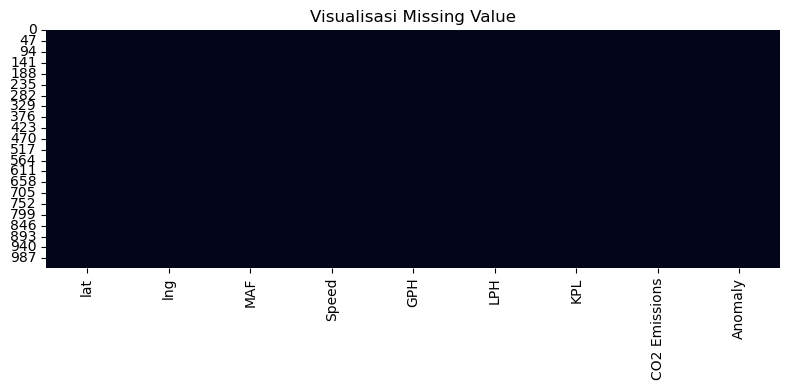

In [29]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Visualisasi Missing Value")

plt.tight_layout()

plt.savefig("../gambar/missing_value.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

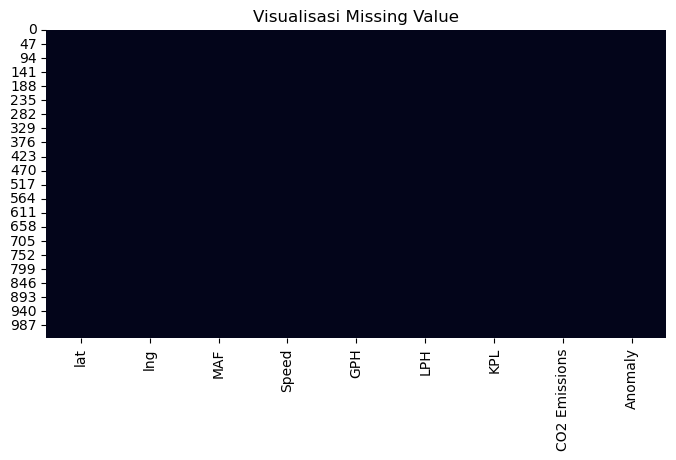

In [30]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Visualisasi Missing Value")

plt.show()

## Distribusi Label Anomaly

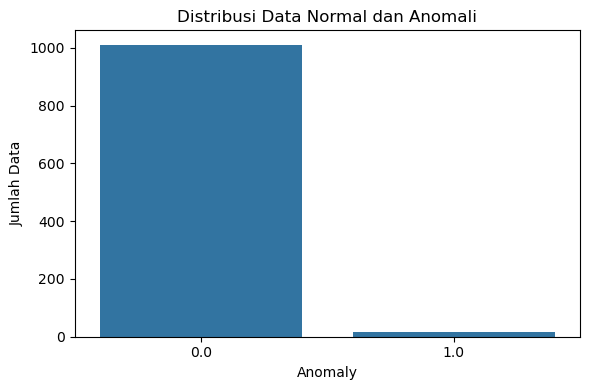

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Anomaly",
    data=df
)

plt.title("Distribusi Data Normal dan Anomali")

plt.xlabel("Anomaly")

plt.ylabel("Jumlah Data")

plt.tight_layout()

plt.savefig("../gambar/distribusi_anomali.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Distribusi Speed

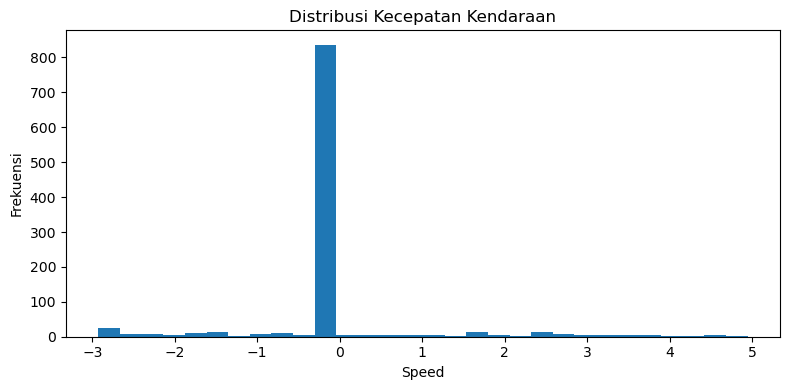

In [32]:
plt.figure(figsize=(8,4))

plt.hist(
    df["Speed"],
    bins=30
)

plt.title("Distribusi Kecepatan Kendaraan")

plt.xlabel("Speed")

plt.ylabel("Frekuensi")

plt.tight_layout()

plt.savefig("../gambar/histogram_speed.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Distribusi MAF

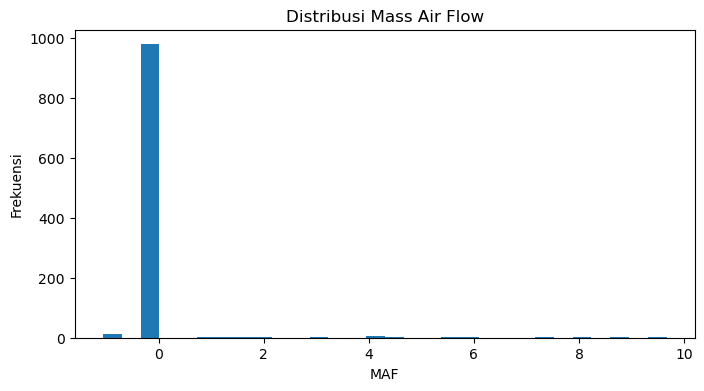

In [33]:
plt.figure(figsize=(8,4))

plt.hist(
    df["MAF"],
    bins=30
)

plt.title("Distribusi Mass Air Flow")

plt.xlabel("MAF")

plt.ylabel("Frekuensi")

plt.show()

## Scatter Plot Speed vs MAF

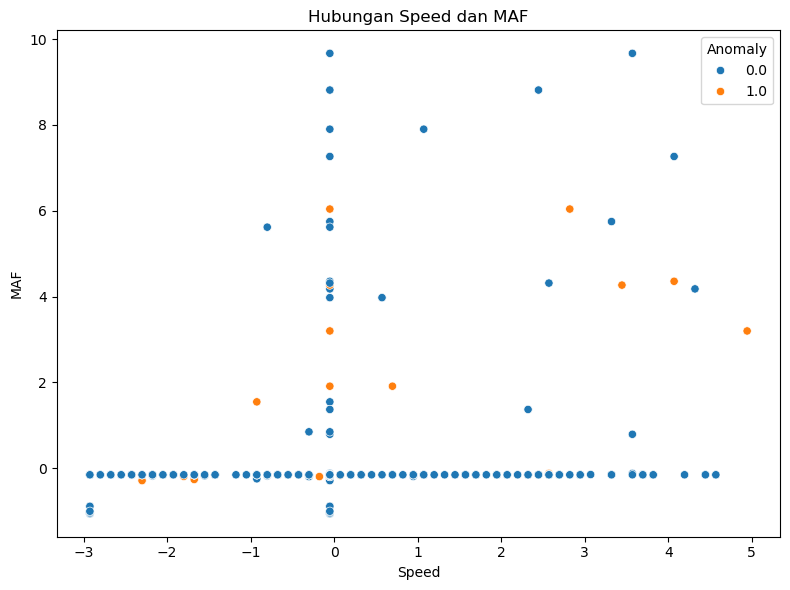

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Speed",
    y="MAF",
    hue="Anomaly",
    data=df
)

plt.title("Hubungan Speed dan MAF")

plt.tight_layout()

plt.savefig("../gambar/scatter_speed_maf.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Korelasi Antar Fitur

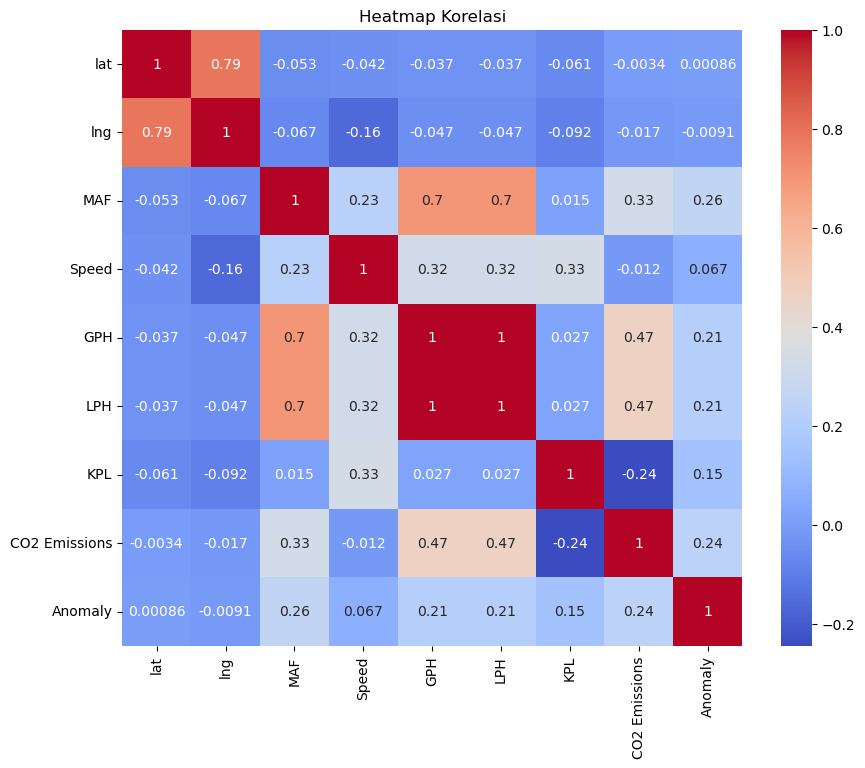

In [35]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Heatmap Korelasi")

plt.show()

## Boxplot Setiap Fitur

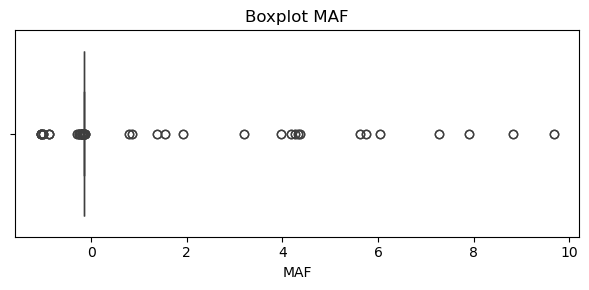

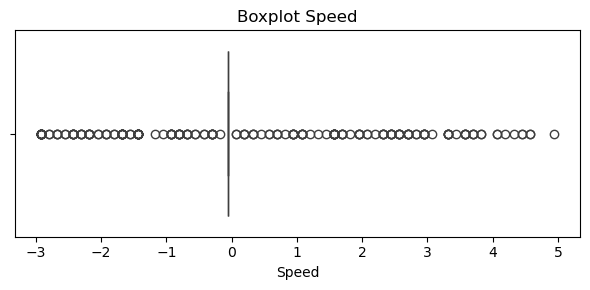

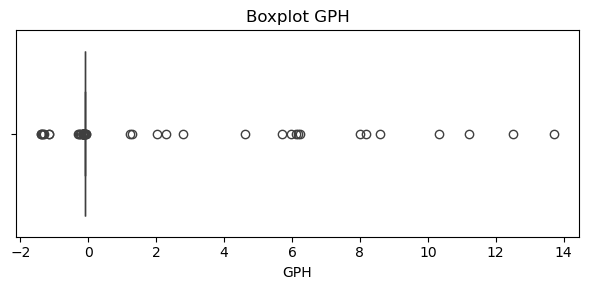

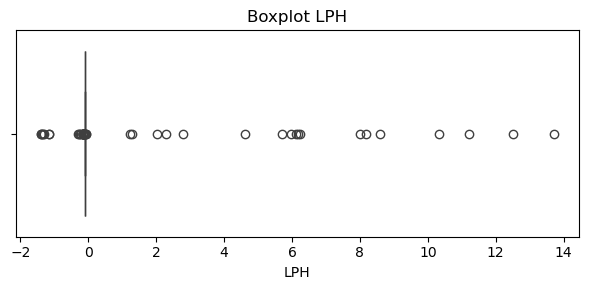

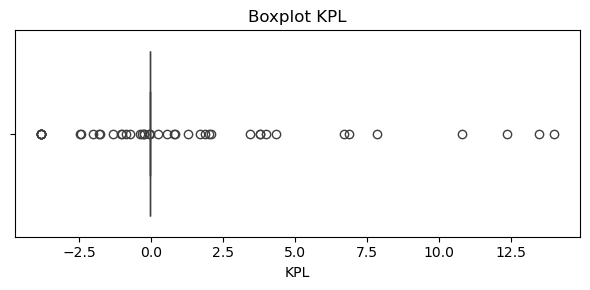

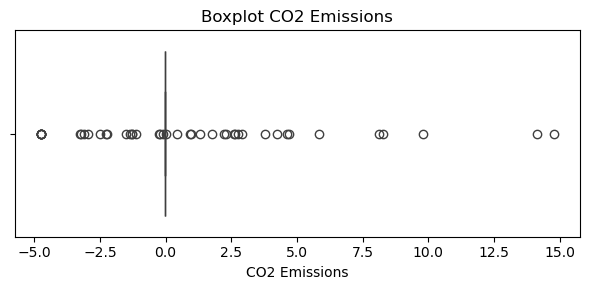

In [36]:
fitur = [
    "MAF",
    "Speed",
    "GPH",
    "LPH",
    "KPL",
    "CO2 Emissions"
]

for kolom in fitur:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[kolom])

    plt.title(f"Boxplot {kolom}")

    plt.tight_layout()

    plt.savefig(f"../gambar/boxplot_{kolom}.png",
                dpi=300,
                bbox_inches="tight")

    plt.show()

## Simpan Visualisasi